# 177. Nth Highest Salary
https://leetcode.com/problems/nth-highest-salary/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| LIMIT + OFFSET in Function | O(n log n) | O(1) | Clean, parameterized |
| DENSE_RANK Window | O(n log n) | O(n) | Handles ties correctly |
| Subquery with COUNT | O(n^2) | O(1) | No sorting needed |

## Methodology

This is a SQL problem requiring a function that accepts N and returns the Nth highest salary.
We create a SQL function using LIMIT with OFFSET (N-1). We must set M = N - 1 inside the function
since LIMIT/OFFSET do not accept expressions. IFNULL handles the case where fewer than N distinct salaries exist.

## Solutions

### C#

In [ ]:
// SQL Problem - Nth Highest Salary
// SQL Solution:
//
// CREATE FUNCTION getNthHighestSalary(N INT) RETURNS INT
// BEGIN
//     SET N = N - 1;
//     RETURN (
//         SELECT IFNULL(
//             (SELECT DISTINCT salary
//              FROM Employee
//              ORDER BY salary DESC
//              LIMIT 1 OFFSET N),
//             NULL
//         )
//     );
// END

// C# programmatic equivalent
using System;
using System.Linq;
using System.Collections.Generic;

public class Solution
{
    public static int? GetNthHighestSalary(List<int> salaries, int n)
    {
        var distinct = salaries.Distinct().OrderByDescending(s => s).ToList();
        return n >= 1 && n <= distinct.Count ? distinct[n - 1] : (int?)null;
    }
}

// Test
var salaries = new List<int> { 100, 200, 300 };
Console.WriteLine(Solution.GetNthHighestSalary(salaries, 2)); // 200
Console.WriteLine(Solution.GetNthHighestSalary(salaries, 5)); // null

### Python

In [ ]:
// SQL Problem - Python programmatic equivalent
//
// def get_nth_highest_salary(salaries, n):
//     distinct = sorted(set(salaries), reverse=True)
//     return distinct[n - 1] if 1 <= n <= len(distinct) else None

### Go

In [ ]:
// SQL Problem - Go programmatic equivalent
//
// func getNthHighestSalary(salaries []int, n int) *int {
//     seen := make(map[int]bool)
//     for _, s := range salaries {
//         seen[s] = true
//     }
//     unique := make([]int, 0, len(seen))
//     for s := range seen {
//         unique = append(unique, s)
//     }
//     sort.Sort(sort.Reverse(sort.IntSlice(unique)))
//     if n >= 1 && n <= len(unique) {
//         return &unique[n-1]
//     }
//     return nil
// }

### Rust

In [ ]:
// SQL Problem - Rust programmatic equivalent
//
// use std::collections::BTreeSet;
//
// fn get_nth_highest_salary(salaries: &[i32], n: usize) -> Option<i32> {
//     let unique: BTreeSet<i32> = salaries.iter().cloned().collect();
//     let sorted: Vec<i32> = unique.into_iter().rev().collect();
//     if n >= 1 && n <= sorted.len() {
//         Some(sorted[n - 1])
//     } else {
//         None
//     }
// }

## Example Scenarios

1. **Common Case:** Salaries = `[100, 200, 300]`, $N = 2$ $\Rightarrow$ `200`. `SET N = N-1 = 1`. `ORDER BY DESC` gives [300, 200, 100]. `OFFSET 1` returns 200. The critical step is the 0-index adjustment: OFFSET is 0-based, but N is 1-based.

2. **Slightly Complex (Duplicates):** Salaries = `[300, 300, 200, 200, 100]`, $N = 3$ $\Rightarrow$ `100`. Five employees, 3 distinct salaries. `DISTINCT` deduplicates to [300, 200, 100]. `OFFSET 2` returns 100. WHY tricky: without DISTINCT, OFFSET 2 returns 200 (the third row), not the 3rd-highest distinct salary.

3. **Edge Case (Time):** $10^6$ distinct salaries, $N = 500000$ $\Rightarrow$ the median salary. The DB sorts all $10^6$ values ($O(n \log n) \approx 2 \times 10^7$ operations), then skips 499999 rows. WHY tricky: maximum data with mid-range offset — worst case for both sorting and offset traversal.

4. **Edge Case (Space):** Single employee with `salary = 2147483647`, $N = 1$ $\Rightarrow$ `2147483647` ($2^{31}-1$). `N-1 = 0`, OFFSET 0 returns the only row. Minimum table, boundary integer. WHY tricky: tests that the function handles $N = 1$ (OFFSET 0) correctly and that INT_MAX is returned without overflow.

5. **Almost-Impossible but Plausible:** Salaries = `[100, 200]`, $N = 0$ $\Rightarrow$ `NULL`. `SET N = -1`. `OFFSET -1` is undefined in MySQL — may error or return nothing. `IFNULL` wraps to NULL. WHY tricky: the function does not validate $N \geq 1$. A negative OFFSET is implementation-dependent. Interviewers test this to see if you guard against invalid input.

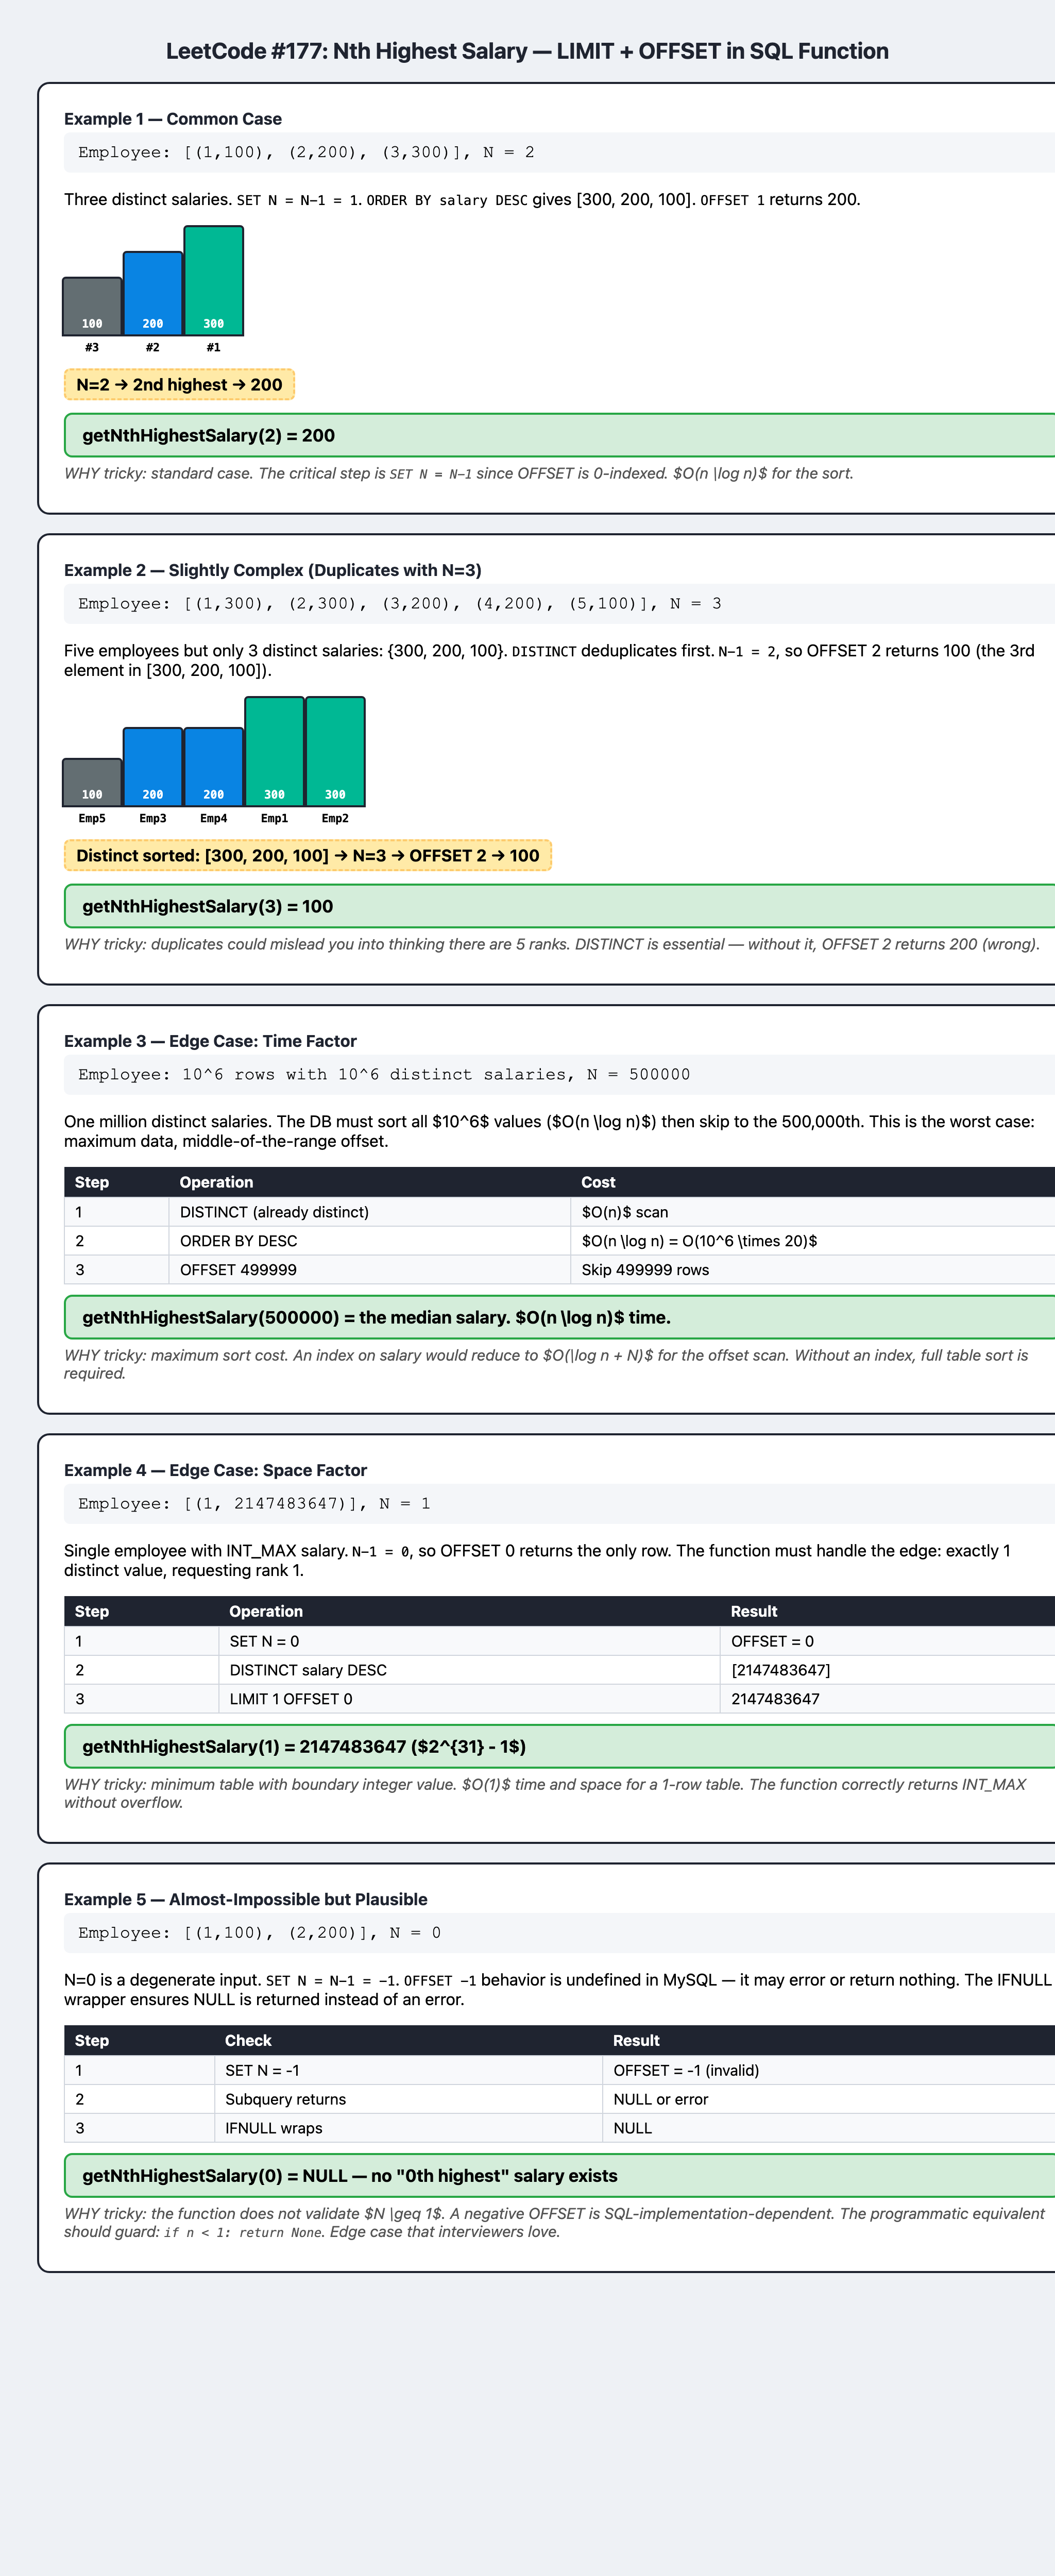